# UMAP view of Forest Sketch representations

This notebook uses the Adult income dataset, including one-hot encoding for categorical variables, to visualize representative embeddings in two dimensions. The panels compare the original encoded features, an initial random projection, one to three Forest Sketch iterations, and selected target dimensions.

UMAP is used only for visualization. It is fit separately on each representation, so distances should be compared within a panel rather than interpreted as a benchmark metric.

In [1]:
import sys
from pathlib import Path
notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists(): notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from forestsketch import ForestSketchEstimator

In [2]:
adult = fetch_openml(name='adult', version=2, as_frame=True)
sample_indices = adult.data.sample(n=min(1800, len(adult.data)), random_state=42).index
raw_X = adult.data.loc[sample_indices].reset_index(drop=True)
raw_y = adult.target.loc[sample_indices].astype(str).str.contains('>50K').astype(int).to_numpy()
numeric_columns = raw_X.select_dtypes(include='number').columns.tolist()
categorical_columns = [column for column in raw_X.columns if column not in numeric_columns]
preprocessor = ColumnTransformer([
    ('numeric', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numeric_columns),
    ('categorical', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore', sparse_output=True)), categorical_columns),
])
X_train_raw, X_vis_raw, y_train, y_vis = train_test_split(raw_X, raw_y, test_size=0.35, stratify=raw_y, random_state=42)
X_train = preprocessor.fit_transform(X_train_raw)
X_vis = preprocessor.transform(X_vis_raw)
print(f"Adult rows used: {len(raw_X):,}; one-hot features: {X_train.shape[1]:,}; sparse={hasattr(X_train, 'tocsr')}")

Adult rows used: 1,800; one-hot features: 94; sparse=True


In [3]:
def forest(seed=42):
    return RandomForestClassifier(n_estimators=35, max_depth=10, n_jobs=1, random_state=seed)

representations = {'Original one-hot': X_vis}
for iterations in [0, 1, 2, 3]:
    sketch = ForestSketchEstimator(
        estimator=forest(), n_components=16, n_iterations=iterations, random_state=42
    )
    sketch.fit(X_train, y_train)
    representations[f'Forest Sketch T={iterations}, d=16'] = sketch.transform(X_vis)
for dimension in [8, 64]:
    sketch = ForestSketchEstimator(
        estimator=forest(), n_components=dimension, n_iterations=2, random_state=42
    )
    sketch.fit(X_train, y_train)
    representations[f'Forest Sketch T=2, d={dimension}'] = sketch.transform(X_vis)

embeddings = {}
for name, representation in representations.items():
    reducer = umap.UMAP(n_neighbors=20, min_dist=0.15, metric='cosine', random_state=42, n_jobs=1)
    embeddings[name] = reducer.fit_transform(representation)
print(f'Generated {len(embeddings)} UMAP embeddings for {X_vis.shape[0]:,} visualization rows.')

Generated 7 UMAP embeddings for 630 visualization rows.


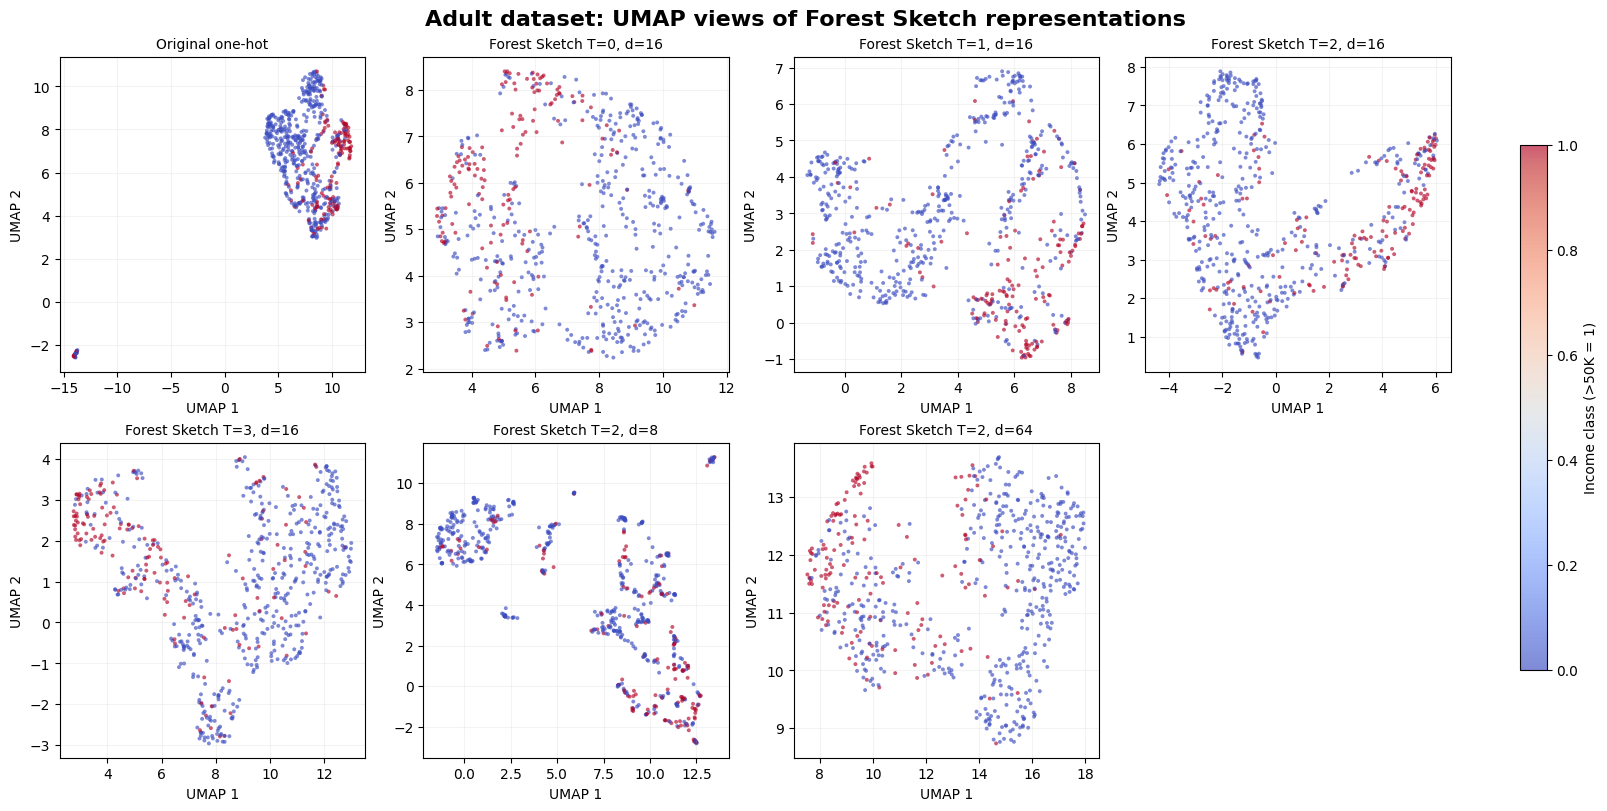

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
fig.suptitle('Adult dataset: UMAP views of Forest Sketch representations', fontsize=16, fontweight='bold')
for axis, (name, embedding) in zip(axes.flat, embeddings.items()):
    scatter = axis.scatter(embedding[:, 0], embedding[:, 1], c=y_vis, cmap='coolwarm', s=8, alpha=0.65, linewidths=0)
    axis.set_title(name, fontsize=10)
    axis.set_xlabel('UMAP 1')
    axis.set_ylabel('UMAP 2')
    axis.grid(alpha=0.15)
for axis in axes.flat[len(embeddings):]: axis.axis('off')
fig.colorbar(scatter, ax=axes, shrink=0.75, label='Income class (>50K = 1)')
plt.show()